# Projet IA — Classification des stations IRVE

Ce notebook a pour objectif de construire un modèle de classification capable de prédire le type d'implantation d'une borne de recharge pour véhicule électrique (IRVE) à partir de ses caractéristiques techniques et d'accessibilité.

Les données proviennent du jeu de données open data IRVE (Infrastructures de Recharge pour Véhicules Électriques), préalablement nettoyé. Le pipeline complet couvre la sélection des features par analyse de corrélation (V de Cramer), l'encodage et la normalisation des variables, puis la comparaison de plusieurs algorithmes de classification. Face au déséquilibre des classes observé dans les données, une étape de rééquilibrage par SMOTE est appliquée avant d'affiner les meilleurs modèles par recherche d'hyperparamètres (GridSearchCV).



## Sommaire

- [1. Initialisation](#1-initialisation)
  - [1.1 Imports](#11-imports)
  - [1.2 Chargement des données](#12-chargement-des-données)
- [2. Préparation des données](#2-préparation-des-données)
  - [2.1 Suppression des colonnes non pertinentes](#21-suppression-des-colonnes-non-pertinentes)
  - [2.2 Déclaration des colonnes par type](#22-déclaration-des-colonnes-par-type)
  - [2.3 Encodage des booléens](#23-encodage-des-booléens)
  - [2.4 Nettoyage des colonnes catégorielles](#24-nettoyage-des-colonnes-catégorielles)
  - [2.5 Encodage ordinal des catégorielles](#25-encodage-ordinal-des-catégorielles)
  - [2.6 Extraction de l'année de mise en service](#26-extraction-de-lannée-de-mise-en-service)
  - [2.7 Conversion des horaires en heures hebdomadaires](#27-conversion-des-horaires-en-heures-hebdomadaires)
- [3. Préprocessing sklearn](#3-préprocessing-sklearn)
  - [3.1 Split train / test](#31-split-train--test)
  - [3.2 Pipelines et transformation](#32-pipelines-et-transformation)
- [4. Modélisation — Baseline](#4-modélisation--baseline)
  - [4.1 Comparaison de 5 modèles par cross-validation](#41-comparaison-de-5-modèles-par-cross-validation)
  - [4.2 Matrices de confusion](#42-matrices-de-confusion)
- [5. Rééquilibrage des classes (SMOTE)](#5-rééquilibrage-des-classes-smote)
  - [5.1 Application de SMOTE](#51-application-de-smote)
  - [5.2 Réévaluation des modèles](#52-réévaluation-des-modèles)
  - [5.3 Matrices de confusion](#53-matrices-de-confusion)
- [6. Optimisation des hyperparamètres](#6-optimisation-des-hyperparamètres)
  - [6.1 GridSearchCV](#61-gridsearchcv)
  - [6.2 Évaluation des modèles tunés](#62-évaluation-des-modèles-tunés)
  - [6.3 Matrices de confusion](#63-matrices-de-confusion)
- [7. Sauvegarde du modèle final](#7-sauvegarde-du-modèle-final)

## 1. Initialisation
### 1.1 Imports

In [36]:
# Utilitaires standard
import os
import re
import joblib
from collections import defaultdict, Counter

# Calcul scientifique et manipulation de données
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Accès Google Drive (spécifique à Colab)
#from google.colab import drive

# Préprocessing
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Sélection de modèles et évaluation
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    StratifiedKFold,
    GridSearchCV,
)
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

# Modèles de classification
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

# Rééquilibrage des classes
from imblearn.over_sampling import SMOTE

### 1.2 Chargement des données

In [37]:
# Montage de Google Drive pour accéder aux fichiers du projet
#drive.mount("/content/drive/")

csv_path = "IRVE_clean_IA.csv"
df = pd.read_csv(csv_path, encoding="UTF-8")

## 2. Préparation des données
### 2.1 Suppression des colonnes non pertinentes

In [38]:
# Passe 1 : suppression des colonnes administratives, géographiques et métadonnées
# (identifiants, coordonnées, dates de modification, infos open data…)
# Ces colonnes n'apportent aucune information prédictive sur le type d'implantation.
df = df.drop(columns=[
    "nom_amenageur", "siren_amenageur", "contact_amenageur",
    "contact_operateur", "telephone_operateur",
    "nom_enseigne", "id_station_itinerance", "id_station_local",
    "nom_station", "adresse_station",
    "code_insee_commune", "coordonneesXY", "id_pdc_itinerance",
    "id_pdc_local", "num_pdl", "observations",
    "date_maj", "last_modified", "datagouv_dataset_id",
    "datagouv_resource_id", "datagouv_organization_or_owner", "created_at",
    "consolidated_longitude", "consolidated_latitude",
    "consolidated_code_postal", "consolidated_commune",
    "consolidated_is_lon_lat_correct",
    "consolidated_is_code_insee_verified",
    "consolidated_is_code_insee_modified",
])

# Passe 2 : suppression des colonnes avec un V de Cramer < 0.5
# En dessous de ce seuil, l'association avec la cible est trop faible
# pour être utile au modèle.
df = df.drop(columns=[
    "nbre_pdc", "puissance_nominale",
    "prise_type_ef", "prise_type_2", "prise_type_combo_ccs",
    "prise_type_chademo", "prise_type_autre",
    "gratuit", "tarification_eur_kWh", "condition_acces",
    "accessibilite_pmr", "station_deux_roues",
])

### 2.2 Déclaration des colonnes par type
On répartit les colonnes retenues en trois groupes selon leur nature. Ce typage est essentiel pour appliquer les bonnes transformations dans les pipelines de préprocessing.

In [39]:
# Colonnes booléennes (stockées comme chaînes "true"/"false" dans le CSV)
BOOL_COLS = [
    "paiement_acte",
    "paiement_cb",
    "paiement_autre",
    "reservation",
    "cable_t2_attache",
]

# Colonnes catégorielles nominales (texte → encodage ordinal)
CAT_COLS = [
    "nom_operateur",
    "restriction_gabarit",
    "raccordement",
]

# Colonnes numériques continues
NUM_COLS = [
    "annee_mise_en_service",  # extraite depuis date_mise_en_service (bloc 8)
    "horaires",               # convertie en heures/semaine (bloc 9)
]

TARGET = "implantation_station"
FEATURE_COLS = BOOL_COLS + CAT_COLS + NUM_COLS

### 2.3 Encodage des booléens

In [40]:
def convertir_booleen(valeur):
    # Correspondance entre les valeurs texte/Python et les floats 0.0/1.0
    # "inconnu" et toute valeur non reconnue sont converties en NaN
    # pour être imputées plus tard par le pipeline
    correspondances = {
        "true": 1.0,
        "false": 0.0,
        "inconnu": np.nan,
        True: 1.0,
        False: 0.0,
    }
    cle = str(valeur).strip().lower()
    return correspondances.get(cle, np.nan)

for col in BOOL_COLS:
    df[col] = df[col].map(convertir_booleen)

### 2.4 Nettoyage des colonnes catégorielles

In [41]:
# "inconnu" n'est pas une catégorie valide : c'est une valeur manquante déguisée.
# On la remplace par NaN pour que l'OrdinalEncoder et l'imputer la traitent correctement.
for col in CAT_COLS:
    df[col] = df[col].replace("inconnu", np.nan)

### 2.5 Encodage ordinal des catégorielles

Les colonnes catégorielles sont converties en entiers via un OrdinalEncoder. Ce choix est cohérent avec les modèles utilisés (arbres de décision, forêts aléatoires) qui n'ont pas besoin d'un encodage one-hot et supportent bien les entiers ordinaux. Les valeurs manquantes et inconnues sont encodées en -1 pour être distinguées des vraies catégories, puis retraitées avant l'imputation.

In [42]:
# Conversion des catégories texte en entiers (0, 1, 2…)
# Les valeurs inconnues et les NaN sont encodés en -1 (valeur sentinelle)
# pour les distinguer des vraies catégories.
# Ces -1 seront reconvertis en NaN avant l'imputation (voir bloc 10).
encoder_cat = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1,
    encoded_missing_value=-1,
)
df[CAT_COLS] = encoder_cat.fit_transform(df[CAT_COLS])

joblib.dump(encoder_cat, "ordinalencoder.joblib")

['ordinalencoder.joblib']

### 2.6 Extraction de l'année de mise en service

La colonne date_mise_en_service contient des dates complètes au format texte. On en extrait uniquement l'année, qui est l'information la plus pertinente pour capturer l'ancienneté d'une installation et son éventuelle corrélation avec le type d'implantation.

In [43]:
def extraire_annee(valeur):
    # On extrait les 4 premiers caractères de la date (= l'année)
    # Les valeurs invalides ou "inconnu" sont converties en NaN
    if pd.isna(valeur) or str(valeur).strip().lower() == "inconnu":
        return np.nan
    try:
        return float(str(valeur).strip()[:4])
    except ValueError:
        return np.nan

df["annee_mise_en_service"] = df["date_mise_en_service"].map(extraire_annee)
# La colonne originale n'est plus nécessaire
df.drop(columns=["date_mise_en_service"], inplace=True)

### 2.7 Conversion des horaires en heures hebdomadaires


La colonne horaires contient des plages d'ouverture en texte libre (ex. mo-fr 08:00-20:00), inexploitables directement par un modèle. On la transforme en une valeur numérique continue représentant le nombre total d'heures d'ouverture par semaine, plus synthétique et porteuse d'information sur le profil d'usage de la borne.

In [44]:
DAYS_ORDER = ["mo", "tu", "we", "th", "fr", "sa", "su"]

def expand_days(day_part):
    # Développe une expression de jours en liste atomique
    # Supporte les virgules ("mo,we") et les plages ("mo-fr")
    day_part = day_part.strip()
    if "," in day_part:
        result = []
        for d in day_part.split(","):
            result.extend(expand_days(d.strip()))
        return result
    if "-" in day_part:
        start, end = day_part.split("-")
        if start not in DAYS_ORDER or end not in DAYS_ORDER:
            return []
        i1, i2 = DAYS_ORDER.index(start), DAYS_ORDER.index(end)
        if i1 <= i2:
            return DAYS_ORDER[i1:i2 + 1]
        # Gestion des plages qui passent minuit (ex: sa-mo)
        return DAYS_ORDER[i1:] + DAYS_ORDER[:i2 + 1]
    return [day_part] if day_part in DAYS_ORDER else []

def parse_hours(h):
    # Extrait les bornes d'une plage horaire au format "HH:MM-HH:MM"
    m = re.match(r"^\s*(\d{2}:\d{2})\s*-\s*(\d{2}:\d{2})\s*$", h)
    if not m:
        return None
    return m.group(1), m.group(2)

def parse_line(line):
    # Parse une ligne d'horaires complète en dict {jour: [(début, fin), …]}
    if not isinstance(line, str):
        return {}
    result = defaultdict(list)
    line = line.replace(";", ",")
    line = re.sub(r"\s+", " ", line.strip())
    blocks = re.findall(r"([a-z, -]+)\s+(\d{2}:\d{2}\s*-\s*\d{2}:\d{2})", line)
    for days_raw, hours_raw in blocks:
        days = expand_days(days_raw)
        hours = parse_hours(hours_raw)
        if not days or not hours:
            continue
        start, end = hours
        for d in days:
            result[d].append((start, end))
    return dict(result)

df["horaires"] = df["horaires"].map(parse_line)

def time_to_minutes(t):
    # Convertit "HH:MM" en nombre de minutes depuis minuit
    h, m = map(int, t.split(":"))
    return h * 60 + m

def weekly_hours(schedule):
    # Somme toutes les plages horaires de la semaine et retourne le total en heures
    total_minutes = 0
    for periods in schedule.values():
        for start, end in periods:
            total_minutes += time_to_minutes(end) - time_to_minutes(start)
    return round(total_minutes / 60, 2)

df["horaires"] = df["horaires"].map(weekly_hours)

## 3. Préprocessing sklearn
### 3.1 Split train / test

On sépare le dataset en un ensemble d'entraînement (80%) et un ensemble de test (20%) avant toute transformation. Cette séparation est impérative : le pipeline de préprocessing sera ajusté (fit) uniquement sur le train, puis appliqué (transform) au test - ce qui évite toute fuite d'information (data leakage) vers les données d'évaluation.

In [45]:
X = df[FEATURE_COLS]
y = df[TARGET]

# 80% train / 20% test, stratifié pour garder les mêmes proportions de classes
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y,
)

### 3.2 Pipelines et transformation

In [46]:
# Pas de scaler sur les booléens : 0 et 1 sont déjà bornés et comparables
bool_pipeline = Pipeline([
    # SimpleImputer: gère les valeurs manquantes.
    # strategy='most_frequent': remplace les NaN par la valeur la plus fréquente (le mode) de la colonne.
    ("imputer", SimpleImputer(strategy="most_frequent")),
])

# Pas de scaler sur les catégorielles : les entiers représentent des catégories,
# pas des quantités - les mettre à l'échelle n'aurait pas de sens
cat_pipeline = Pipeline([
    # SimpleImputer: gère les valeurs manquantes.
    # strategy='most_frequent': remplace les NaN par la valeur la plus fréquente de la colonne.
    ("imputer", SimpleImputer(strategy="most_frequent")),
])

# RobustScaler pour les numériques : moins sensible aux valeurs aberrantes
# que StandardScaler grâce à l'utilisation de la médiane et de l'IQR
num_pipeline = Pipeline([
    # SimpleImputer: gère les valeurs manquantes.
    # strategy='median': remplace les NaN par la médiane de la colonne.
    ("imputer", SimpleImputer(strategy="median")),
    # RobustScaler: Met les caractéristiques à l'échelle en utilisant des statistiques robustes aux valeurs aberrantes.
    # Centre les données sur la médiane et les met à l'échelle en fonction de l'écart interquartile (IQR).
    ("scaler", RobustScaler()),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("bool", bool_pipeline, BOOL_COLS),
        ("cat",  cat_pipeline,  CAT_COLS),
        ("num",  num_pipeline,  NUM_COLS),
    ],
    # remainder='drop': Supprime toutes les colonnes qui ne sont pas spécifiées dans 'transformers'.
    remainder="drop",
)

# Reconversion des -1 (sentinelle OrdinalEncoder) en NaN avant imputation
X_train = X_train.replace(-1, np.nan)
X_test  = X_test.replace(-1, np.nan)

# fit uniquement sur le train pour éviter toute fuite d'information vers le test
# fit_transform: Applique fit (apprend les paramètres de transformation) puis transform (applique la transformation) sur X_train.
X_train_prep = preprocessor.fit_transform(X_train)
# transform: Applique uniquement la transformation (avec les paramètres appris sur X_train) sur X_test.
X_test_prep  = preprocessor.transform(X_test)

# Sauvegarde du préprocesseur et des données transformées sur Drive
#os.makedirs("/content/drive/MyDrive/tp_IA/Projet_IA/models", exist_ok=True)

# joblib.dump: Sérialise et sauvegarde l'objet Python (ici le preprocessor) dans un fichier.
joblib.dump(preprocessor, "preprocessor.joblib")

['preprocessor.joblib']

## 4. Modélisation — Baseline
### 4.1 Comparaison de 5 modèles par cross-validation

Avant toute optimisation, on établit une baseline en comparant cinq algorithmes de classification aux configurations par défaut. Ce panorama permet d'identifier rapidement les familles de modèles les plus prometteuses sur ce problème avant d'investir du temps en tuning.

Les modèles retenus couvrent des approches variées :
- Logistic Regression - modèle linéaire, rapide et interprétable, bon point de comparaison
- Random Forest - ensemble d'arbres, robuste et performant sur des données hétérogènes
- Gradient Boosting - boosting séquentiel, souvent très performant mais plus lent
- K-Nearest Neighbors - classification par proximité, sensible à l'échelle des features
- Decision Tree - arbre simple, très interprétable mais sujet au surapprentissage

Chaque modèle est évalué par cross-validation stratifiée à 5 folds sur le train set, puis entraîné sur le train complet et évalué sur le test set.

In [47]:
models = {
    # LogisticRegression: Modèle linéaire pour la classification.
    # random_state=42: Pour la reproductibilité des résultats.
    # solver='liblinear': Algorithme d'optimisation, bon pour les petits datasets et le one-vs-rest.
    # multi_class='ovr': Stratégie One-vs-Rest pour la classification multi-classes.
    "Logistic Regression": LogisticRegression(random_state=42, solver="liblinear", multi_class="ovr"),

    # RandomForestClassifier: Forêt d'arbres de décision.
    # random_state=42: Pour la reproductibilité des résultats.
    "Random Forest":       RandomForestClassifier(random_state=42),

    # GradientBoostingClassifier: Boosting d'arbres de décision.
    # random_state=42: Pour la reproductibilité des résultats.
    "Gradient Boosting":   GradientBoostingClassifier(random_state=42),

    # KNeighborsClassifier: Algorithme des plus proches voisins.
    "K-Nearest Neighbors": KNeighborsClassifier(),

    # DecisionTreeClassifier: Arbre de décision unique.
    # random_state=42: Pour la reproductibilité des résultats.
    "Decision Tree":       DecisionTreeClassifier(random_state=42),
}

cv_results_original = {}
print("\n--- Cross-validation Results (Original Data) ---")
for name, model in models.items():
    print(f"Performing cross-validation for {name}...")
    # StratifiedKFold: Stratégie de validation croisée qui préserve la proportion des classes
    # sur chaque pli (fold). Essentiel pour les datasets déséquilibrés.
    #   n_splits=5: Nombre de plis (folds) à générer.
    #   shuffle=True: Mélange les données avant de les diviser en plis.
    #   random_state=42: Graine aléatoire pour la reproductibilité du mélange.
    strat_k_fold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # cross_val_score: Évalue un estimateur en utilisant la validation croisée.
    #   estimator (model): L'objet estimateur à évaluer (ici, un modèle de classification).
    #   X (X_train_prep): Les données d'entraînement prétraitées.
    #   y (y_train): Les étiquettes cibles pour l'entraînement.
    #   cv (strat_k_fold): La stratégie de validation croisée à utiliser.
    #   scoring="accuracy": La métrique à utiliser pour évaluer la performance.
    #   n_jobs=-1: Utilise tous les cœurs de processeur disponibles pour un calcul plus rapide.
    scores = cross_val_score(model, X_train_prep, y_train, cv=strat_k_fold, scoring="accuracy", n_jobs=-1)
    cv_results_original[name] = {
        "mean_accuracy": scores.mean(),
        "std_accuracy": scores.std(),
        "all_scores": scores,
    }
    print(f"  {name} — Mean Accuracy: {scores.mean():.4f} (+/- {scores.std():.4f})")

# Entraînement sur le train complet puis évaluation sur le test set
print("\n--- Model Evaluation on Test Set (Original Data) ---")
results = {}
for name, model in models.items():
    print(f"\nTraining {name}...")
    # fit: Entraîne le modèle sur l'ensemble des données d'entraînement.
    model.fit(X_train_prep, y_train)
    # predict: Prédit les étiquettes de classe pour les données de test.
    y_pred = model.predict(X_test_prep)
    # accuracy_score: Calcule la précision de la classification.
    accuracy = accuracy_score(y_test, y_pred)
    results[name] = {
        "accuracy": accuracy,
        # classification_report: Génère un rapport texte montrant les principales métriques de classification
        # (précision, rappel, f1-score, support) par classe.
        # output_dict=True: Retourne le rapport sous forme de dictionnaire pour un traitement ultérieur.
        "report": classification_report(y_test, y_pred, output_dict=True),
    }
    print(f"  {name} — Test Accuracy: {accuracy:.4f}")
    print(classification_report(y_test, y_pred))


--- Cross-validation Results (Original Data) ---
Performing cross-validation for Logistic Regression...


/home/pierre-luc/Documents/GitHub/Projet_IA/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/pierre-luc/Documents/GitHub/Projet_IA/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/pierre-luc/Documents/GitHub/Projet_IA/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/hom

  Logistic Regression — Mean Accuracy: 0.5778 (+/- 0.0037)
Performing cross-validation for Random Forest...
  Random Forest — Mean Accuracy: 0.8862 (+/- 0.0015)
Performing cross-validation for Gradient Boosting...
  Gradient Boosting — Mean Accuracy: 0.8671 (+/- 0.0035)
Performing cross-validation for K-Nearest Neighbors...
  K-Nearest Neighbors — Mean Accuracy: 0.8741 (+/- 0.0048)
Performing cross-validation for Decision Tree...
  Decision Tree — Mean Accuracy: 0.8862 (+/- 0.0015)

--- Model Evaluation on Test Set (Original Data) ---

Training Logistic Regression...


/home/pierre-luc/Documents/GitHub/Projet_IA/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


  Logistic Regression — Test Accuracy: 0.5777
                                      precision    recall  f1-score   support

Parking privé réservé à la clientèle       0.00      0.00      0.00       377
        Parking privé à usage public       0.55      0.74      0.63      8566
                      Parking public       0.41      0.12      0.18      5995
 Station dédiée à la recharge rapide       0.50      0.35      0.41      1803
                              Voirie       0.64      0.76      0.70     10688

                            accuracy                           0.58     27429
                           macro avg       0.42      0.39      0.38     27429
                        weighted avg       0.54      0.58      0.53     27429


Training Random Forest...
  Random Forest — Test Accuracy: 0.8889
                                      precision    recall  f1-score   support

Parking privé réservé à la clientèle       0.58      0.87      0.69       377
        Parking privé à u

### Analyse des résultats (Baseline)

Les modèles basés sur les arbres (Random Forest et Decision Tree) affichent les meilleures performances, avec une précision moyenne d'environ 0.886 en cross-validation et une accuracy d'environ 0.889 sur le jeu de test. Le Gradient Boosting et les K-Nearest Neighbors sont également performants, mais légèrement en deçà.

La régression logistique, un modèle linéaire, obtient des résultats bien inférieurs, avec une précision moyenne d'environ 0.578.

Il est important de noter que malgré une bonne accuracy globale pour les meilleurs modèles, le rapport de classification (classification_report) révèle un déséquilibre : les classes minoritaires, notamment 'Parking privé réservé à la clientèle', affichent des scores de précision et de rappel très faibles, ce qui indique que les modèle a du mal à les identifier correctement.

### 4.2 Matrices de confusion
Les matrices de confusion des deux meilleurs modèles permettent d'aller au-delà du score d'accuracy et d'identifier quelles classes sont les plus souvent confondues entre elles.

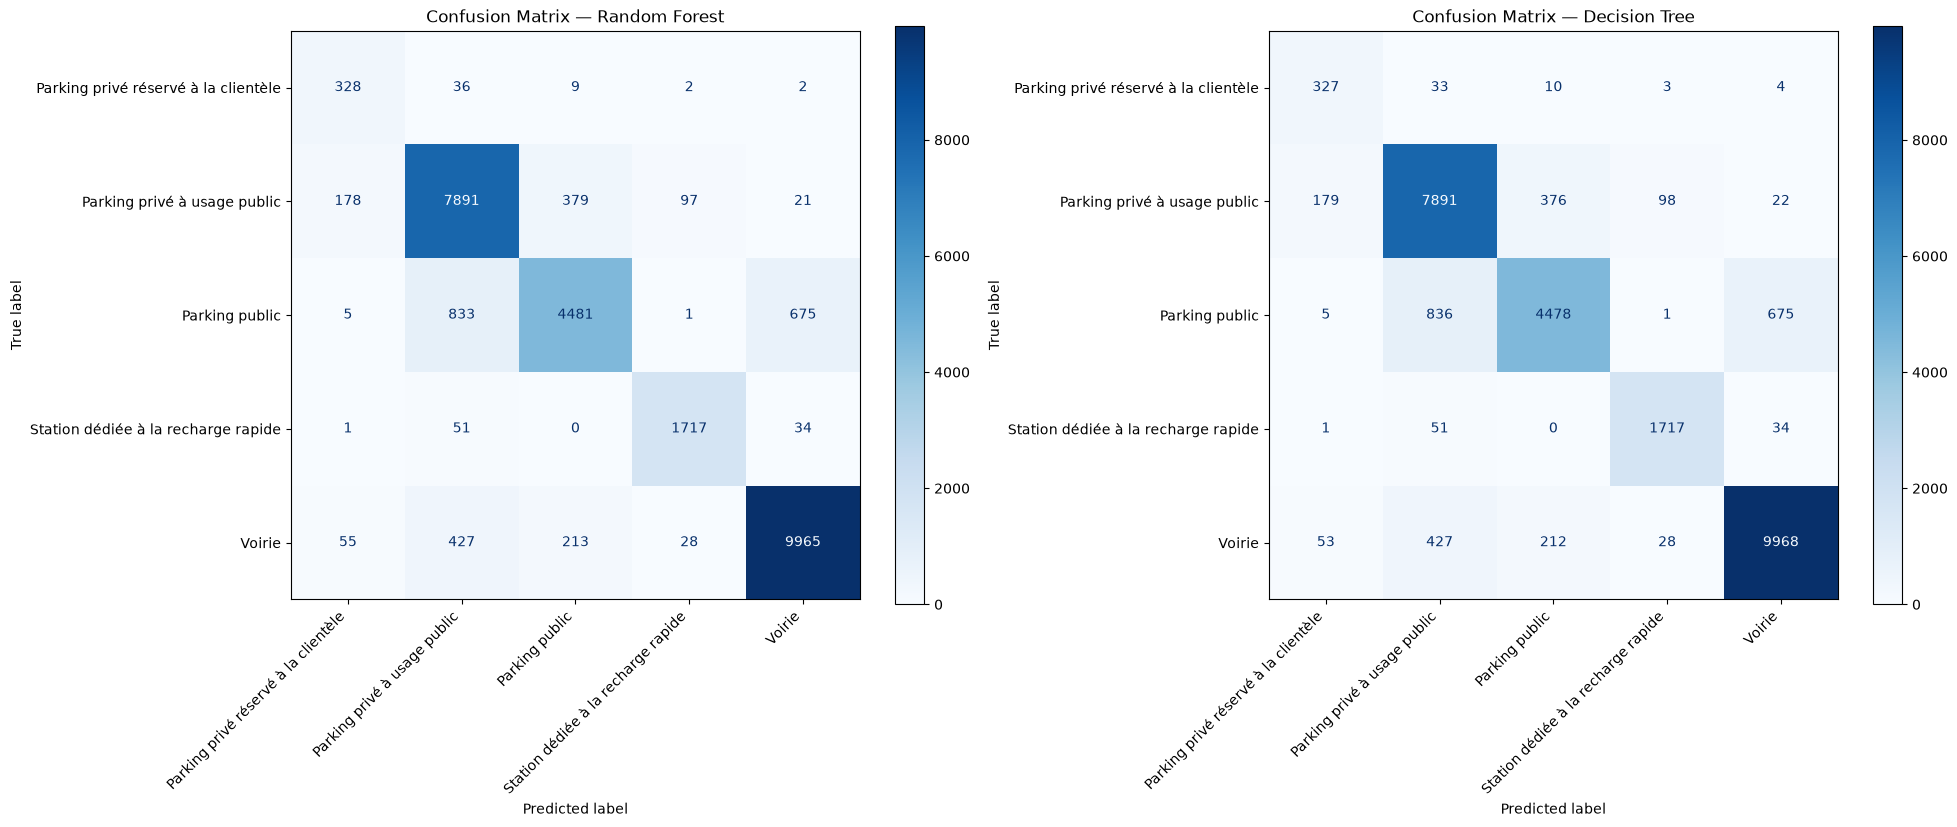

In [48]:
# Visualisation des erreurs de classification pour les deux meilleurs modèles.
# La matrice de confusion révèle quelles classes sont confondues entre elles,
# ce qu'un simple score d'accuracy ne montre pas.
best_models_names = ["Random Forest", "Decision Tree"]

# Crée une figure et un ensemble de sous-graphiques (axes) pour afficher les matrices.
# 1, 2: signifie 1 ligne et 2 colonnes de sous-graphiques.
# figsize=(20, 8): définit la taille de la figure en pouces.
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
for i, name in enumerate(best_models_names):
    model = models[name]
    # ConfusionMatrixDisplay.from_estimator: Crée et affiche une matrice de confusion.
    #   estimator (model): Le modèle entraîné à évaluer.
    #   X (X_test_prep): Les données de test prétraitées.
    #   y (y_test): Les vraies étiquettes des données de test.
    #   display_labels=model.classes_: Les étiquettes à utiliser pour les classes (tirées du modèle).
    #   cmap=plt.cm.Blues: La carte de couleurs à utiliser pour la matrice (un dégradé de bleu).
    #   normalize=None: Ne normalise pas la matrice (affiche les comptes bruts).
    #   ax=axes[i]: Spécifie l'axe sur lequel dessiner la matrice de confusion.
    disp = ConfusionMatrixDisplay.from_estimator(
        model, X_test_prep, y_test,
        display_labels=model.classes_,
        cmap=plt.cm.Blues,
        normalize=None,
        ax=axes[i],
    )
    # Définit le titre de chaque sous-graphique.
    disp.ax_.set_title(f"Confusion Matrix — {name}")
    # Ajuste les propriétés des étiquettes de l'axe des x (rotation pour la lisibilité).
    plt.setp(disp.ax_.get_xticklabels(), rotation=45, ha="right")
    # Ajuste les propriétés des étiquettes de l'axe des y.
    plt.setp(disp.ax_.get_yticklabels(), rotation=0,  ha="right")

# Ajuste automatiquement les paramètres du subplot pour donner un ajustement serré.
plt.tight_layout()
# Affiche la figure avec toutes les matrices de confusion.
plt.show()

### Analyse des matrices de confusion (Baseline)

Les matrices de confusion des deux meilleurs modèles (Random Forest et Decision Tree) confirment les observations du rapport de classification. Bien que l'accuracy globale soit élevée, nous pouvons constater des problèmes de classification pour les classes minoritaires:

- 'Parking privé réservé à la clientèle': Cette classe est la plus petite en termes de support. Pour le Random Forest (et de manière similaire pour le Decision Tree), sur les 377 instances réelles de cette classe dans le jeu de test, seulement 328 (Random Forest) ou 327 (Decision Tree) sont correctement identifiées. Ce comportement est typique des modèles entraînés sur des données déséquilibrées, où ils privilégient les classes majoritaires.

- 'Parking public': Bien que plus nombreuse, cette classe présente aussi un nombre significatif de confusions, notamment avec 'Voirie' et 'Parking privé à usage public', ce qui réduit son score de rappel.

Ces matrices mettent en évidence la nécessité d'un rééquilibrage des classes pour améliorer la capacité des modèles à détecter correctement les types d'implantation sous-représentés.

## 5. Rééquilibrage des classes (SMOTE)
### 5.1 Application de SMOTE

L'analyse de la distribution des classes a révèlé un déséquilibre marqué : certains types d'implantation sont bien plus représentés que d'autres dans le dataset. Un modèle entraîné sur ces données aura tendance à favoriser les classes majoritaires, au détriment des classes rares - ce qui se traduit par une accuracy globale trompeusement élevée mais de mauvaises performances sur les classes minoritaires.

Pour corriger cela, on applique SMOTE (Synthetic Minority Over-sampling Technique) : plutôt que de dupliquer les exemples minoritaires existants, SMOTE en génère de nouveaux par interpolation entre voisins proches, ce qui enrichit réellement l'espace de décision. SMOTE est appliqué uniquement sur le train set pour ne pas contaminer l'évaluation.

In [49]:
# SMOTE génère des exemples synthétiques pour les classes minoritaires
# par interpolation entre voisins proches, afin de rééquilibrer le dataset.
# On l'applique uniquement sur le train set pour éviter toute fuite vers le test.
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_prep, y_train)

print(f"Original class distribution:  {Counter(y_train)}")
print(f"Resampled class distribution: {Counter(y_train_resampled)}")

Original class distribution:  Counter({'Voirie': 42751, 'Parking privé à usage public': 34265, 'Parking public': 23978, 'Station dédiée à la recharge rapide': 7210, 'Parking privé réservé à la clientèle': 1508})
Resampled class distribution: Counter({'Parking public': 42751, 'Voirie': 42751, 'Parking privé à usage public': 42751, 'Parking privé réservé à la clientèle': 42751, 'Station dédiée à la recharge rapide': 42751})


### 5.2 Réévaluation des modèles

On réentraîne les cinq modèles sur les données rééquilibrées pour mesurer l'impact de SMOTE sur leurs performances.

In [50]:
# Chaque modèle est réinitialisé depuis zéro pour un entraînement propre
# sur les données SMOTE. On utilise un dict de lambdas pour éviter
# les if/elif répétitifs et faciliter l'ajout de nouveaux modèles.
model_configs = {
    # LogisticRegression: Modèle linéaire pour la classification.
    # random_state=42: Pour la reproductibilité des résultats.
    # solver='liblinear': Algorithme d'optimisation, bon pour les petits datasets et le one-vs-rest.
    # multi_class='ovr': Stratégie One-vs-Rest pour la classification multi-classes.
    "Logistic Regression": lambda: LogisticRegression(random_state=42, solver="liblinear", multi_class="ovr"),

    # RandomForestClassifier: Forêt d'arbres de décision.
    # random_state=42: Pour la reproductibilité des résultats.
    "Random Forest":       lambda: RandomForestClassifier(random_state=42),

    # GradientBoostingClassifier: Boosting d'arbres de décision.
    # random_state=42: Pour la reproductibilité des résultats.
    "Gradient Boosting":   lambda: GradientBoostingClassifier(random_state=42),

    # KNeighborsClassifier: Algorithme des plus proches voisins.
    "K-Nearest Neighbors": lambda: KNeighborsClassifier(),

    # DecisionTreeClassifier: Arbre de décision unique.
    # random_state=42: Pour la reproductibilité des résultats.
    "Decision Tree":       lambda: DecisionTreeClassifier(random_state=42),
}

cv_results_resampled = {}
print("\n--- Cross-validation Results (Resampled Data) ---")
for name in model_configs:
    # StratifiedKFold: Stratégie de validation croisée qui préserve la proportion des classes
    # sur chaque pli (fold). Essentiel pour les datasets déséquilibrés.
    #   n_splits=5: Nombre de plis (folds) à générer.
    #   shuffle=True: Mélange les données avant de les diviser en plis.
    #   random_state=42: Graine aléatoire pour la reproductibilité du mélange.
    strat_k_fold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # cross_val_score: Évalue un estimateur en utilisant la validation croisée.
    #   estimator (model_configs[name]()): L'objet estimateur à évaluer (un nouveau modèle à chaque itération).
    #   X (X_train_resampled): Les données d'entraînement rééquilibrées par SMOTE.
    #   y (y_train_resampled): Les étiquettes cibles rééquilibrées par SMOTE.
    #   cv (strat_k_fold): La stratégie de validation croisée à utiliser.
    #   scoring="accuracy": La métrique à utiliser pour évaluer la performance.
    #   n_jobs=-1: Utilise tous les cœurs de processeur disponibles pour un calcul plus rapide.
    scores = cross_val_score(
        model_configs[name](), X_train_resampled, y_train_resampled,
        cv=strat_k_fold, scoring="accuracy", n_jobs=-1,
    )
    cv_results_resampled[name] = {"mean_accuracy": scores.mean(), "std_accuracy": scores.std()}
    print(f"  {name} — Mean Accuracy: {scores.mean():.4f} (+/- {scores.std():.4f})")

print("\n--- Model Evaluation on Test Set (Resampled Data) ---")
results_resampled = {}
for name in model_configs:
    model_re = model_configs[name]()
    print(f"\nTraining {name} with resampled data...")
    # fit: Entraîne le modèle sur l'ensemble des données d'entraînement rééquilibrées.
    model_re.fit(X_train_resampled, y_train_resampled)
    # predict: Prédit les étiquettes de classe pour les données de test (non-rééchantillonnées).
    y_pred_resampled = model_re.predict(X_test_prep)
    # accuracy_score: Calcule la précision de la classification sur le jeu de test original.
    accuracy_resampled = accuracy_score(y_test, y_pred_resampled)
    results_resampled[name] = {
        "accuracy": accuracy_resampled,
        # classification_report: Génère un rapport texte montrant les principales métriques de classification
        # (précision, rappel, f1-score, support) par classe, sur le jeu de test original.
        # output_dict=True: Retourne le rapport sous forme de dictionnaire pour un traitement ultérieur.
        "report": classification_report(y_test, y_pred_resampled, output_dict=True),
    }
    print(f"  {name} — Test Accuracy (Resampled): {accuracy_resampled:.4f}")
    print(classification_report(y_test, y_pred_resampled))


--- Cross-validation Results (Resampled Data) ---


/home/pierre-luc/Documents/GitHub/Projet_IA/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/pierre-luc/Documents/GitHub/Projet_IA/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/pierre-luc/Documents/GitHub/Projet_IA/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/hom

  Logistic Regression — Mean Accuracy: 0.4742 (+/- 0.0019)
  Random Forest — Mean Accuracy: 0.9071 (+/- 0.0007)
  Gradient Boosting — Mean Accuracy: 0.8845 (+/- 0.0011)
  K-Nearest Neighbors — Mean Accuracy: 0.7931 (+/- 0.0173)
  Decision Tree — Mean Accuracy: 0.9068 (+/- 0.0007)

--- Model Evaluation on Test Set (Resampled Data) ---

Training Logistic Regression with resampled data...


/home/pierre-luc/Documents/GitHub/Projet_IA/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


  Logistic Regression — Test Accuracy (Resampled): 0.4125
                                      precision    recall  f1-score   support

Parking privé réservé à la clientèle       0.04      0.51      0.07       377
        Parking privé à usage public       0.52      0.44      0.48      8566
                      Parking public       0.26      0.16      0.20      5995
 Station dédiée à la recharge rapide       0.32      0.79      0.46      1803
                              Voirie       0.75      0.46      0.57     10688

                            accuracy                           0.41     27429
                           macro avg       0.38      0.47      0.35     27429
                        weighted avg       0.53      0.41      0.45     27429


Training Random Forest with resampled data...
  Random Forest — Test Accuracy (Resampled): 0.8769
                                      precision    recall  f1-score   support

Parking privé réservé à la clientèle       0.50      0.93  

### Analyse des résultats (Après rééquilibrage)

Après l'application de SMOTE, on observe un impact significatif sur les performances des modèles, en particulier sur leur capacité à gérer les classes minoritaires:

- Augmentation des métriques pour les classes minoritaires: Le but de SMOTE est atteint. Si l'accuracy globale sur le jeu de test reste similaire pour les modèles basés sur les arbres (autour de 0.877), on constate une nette amélioration du recall (et donc du f1-score) pour la classe 'Parking privé réservé à la clientèle'. Par exemple, le Random Forest voit son recall passer de 0.87 (sans SMOTE) à 0.93 (avec SMOTE) pour cette classe, bien que la précision diminue légèrement. Ceci indique que le modèle identifie désormais beaucoup plus d'instances de cette classe, au prix de quelques faux positifs.

- Random Forest et Decision Tree: Ces deux modèles conservent les meilleures performances globales et montrent la meilleure capacité à équilibrer précision et rappel pour l'ensemble des classes après SMOTE.

### 5.3 Matrices de confusion

La comparaison de ces matrices avec celles du bloc 4.2 permet de visualiser concrètement l'effet du rééquilibrage sur les classes minoritaires.

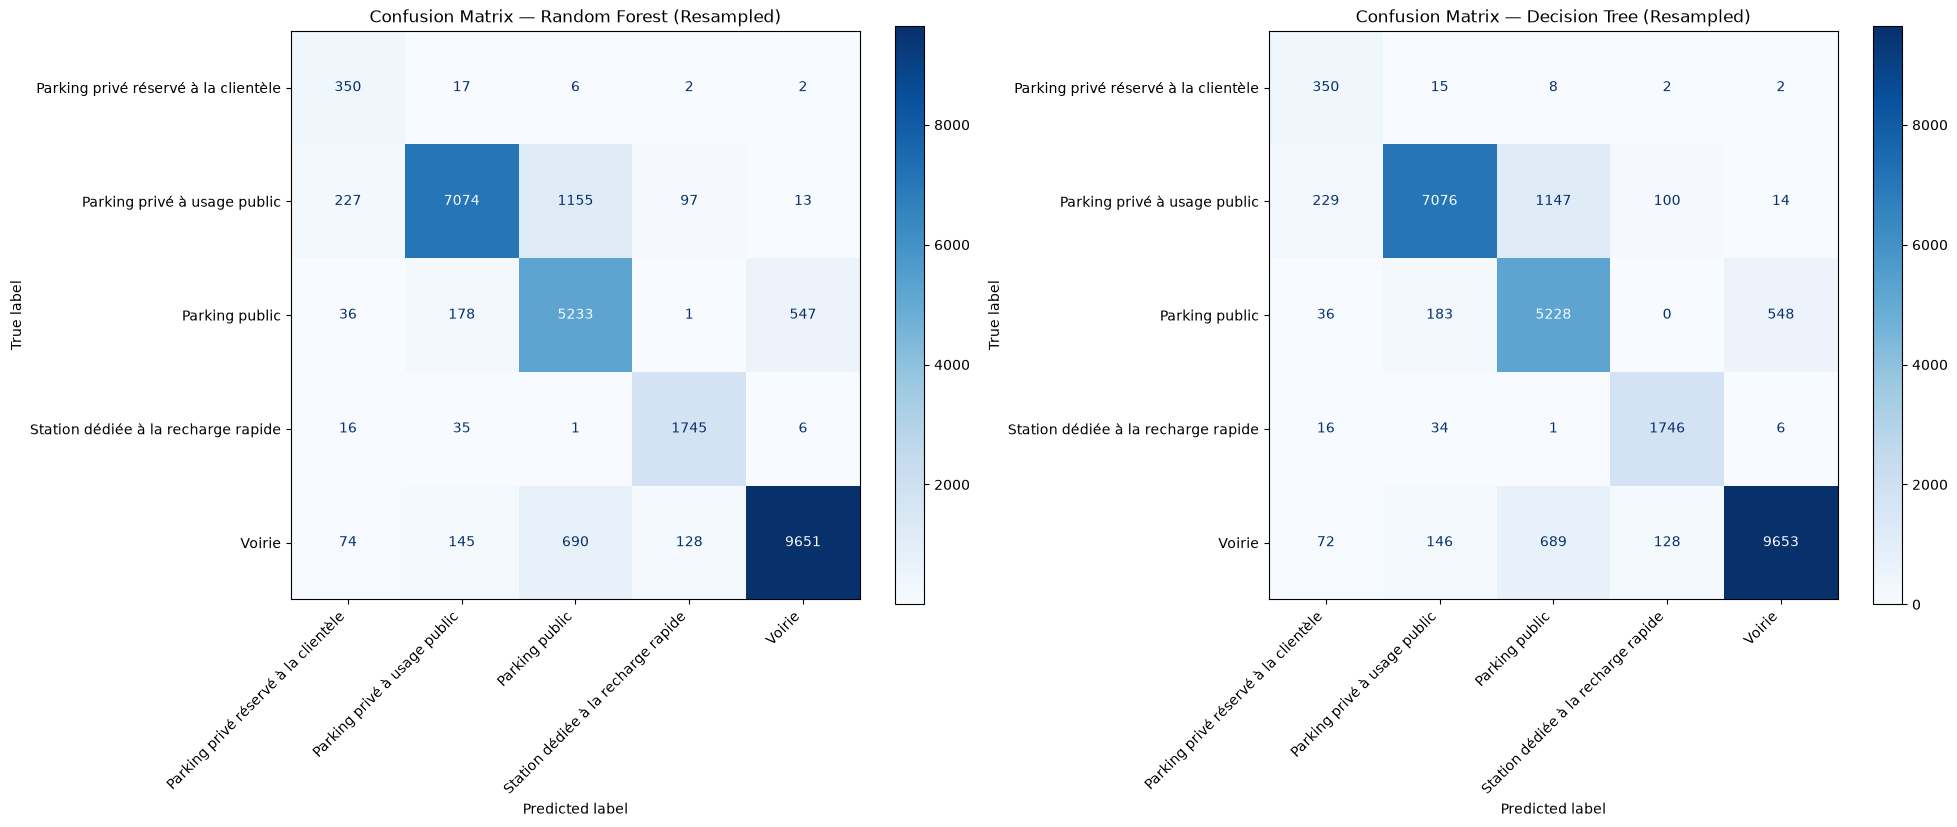

In [51]:
# On réentraîne les deux meilleurs modèles sur les données SMOTE
# pour comparer leurs matrices de confusion avec celles du bloc 12.
best_models_names = ["Random Forest", "Decision Tree"]
trained_models_resampled = {}

# Entraîne les modèles sur les données rééchantillonnées (SMOTE).
for name in best_models_names:
    # model_configs[name](): Crée une nouvelle instance du modèle (RandomForestClassifier ou DecisionTreeClassifier).
    model_re = model_configs[name]()
    # fit: Entraîne le modèle sur les données d'entraînement rééquilibrées.
    model_re.fit(X_train_resampled, y_train_resampled)
    trained_models_resampled[name] = model_re

# Crée une figure et un ensemble de sous-graphiques (axes) pour afficher les matrices.
# 1, 2: signifie 1 ligne et 2 colonnes de sous-graphiques.
# figsize=(20, 8): définit la taille de la figure en pouces.
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
for i, name in enumerate(best_models_names):
    model = trained_models_resampled[name]
    # ConfusionMatrixDisplay.from_estimator: Crée et affiche une matrice de confusion.
    #   estimator (model): Le modèle entraîné à évaluer.
    #   X (X_test_prep): Les données de test prétraitées (non rééchantillonnées).
    #   y (y_test): Les vraies étiquettes des données de test.
    #   display_labels=model.classes_: Les étiquettes à utiliser pour les classes (tirées du modèle).
    #   cmap=plt.cm.Blues: La carte de couleurs à utiliser pour la matrice.
    #   normalize=None: Ne normalise pas la matrice (affiche les comptes bruts).
    #   ax=axes[i]: Spécifie l'axe sur lequel dessiner la matrice de confusion.
    disp = ConfusionMatrixDisplay.from_estimator(
        model, X_test_prep, y_test,
        display_labels=model.classes_,
        cmap=plt.cm.Blues,
        normalize=None,
        ax=axes[i],
    )
    # Définit le titre de chaque sous-graphique.
    disp.ax_.set_title(f"Confusion Matrix — {name} (Resampled)")
    # Ajuste les propriétés des étiquettes de l'axe des x (rotation pour la lisibilité).
    plt.setp(disp.ax_.get_xticklabels(), rotation=45, ha="right")
    # Ajuste les propriétés des étiquettes de l'axe des y.
    plt.setp(disp.ax_.get_yticklabels(), rotation=0,  ha="right")

# Ajuste automatiquement les paramètres du subplot pour donner un ajustement serré.
plt.tight_layout()
# Affiche la figure avec toutes les matrices de confusion.
plt.show()

### Analyse des matrices de confusion (Après rééquilibrage)

La visualisation des matrices de confusion après SMOTE confirme l'efficacité du rééquilibrage des classes, en particulier pour la classe minoritaire 'Parking privé réservé à la clientèle':

- Amélioration de la détection des minoritaires: Pour le Random Forest et le Decision Tree, le nombre d'instances correctement classées pour 'Parking privé réservé à la clientèle' a considérablement augmenté, passant de ,respectiement, 328 et 327 à 350 sur les 377 instances réelles. Cela signifie que le modèle détecte presque toutes les instances de cette classe.

- Compromis sur la précision: Cette amélioration du recall s'accompagne d'une légère dégradation de la precision pour cette classe. On observe que le modèle est plus enclin à prédire 'Parking privé réservé à la clientèle', ce qui conduit à un plus grand nombre de faux positifs pour cette classe. Par exemple, des instances de 'Parking privé à usage public' (17 pour RF, 15 pour DT) ou 'Parking public' (6 pour RF, 8 pour DT) sont maintenant prédites comme 'Parking privé réservé à la clientèle'. Cependant, cet échange est souvent acceptable lorsque la détection des classes minoritaires est critique.

- Stabilité des autres classes: Les performances pour les classes majoritaires restent globalement très bonnes. Les confusions principales continuent d'exister entre les classes 'Parking privé à usage public', 'Parking public', et 'Voirie', mais sans dégradation majeure par rapport aux résultats de baseline.

Ces matrices démontrent que SMOTE a bien réorienté les modèles vers une meilleure considération des classes sous-représentées, améliorant la robustesse du classifieur face au déséquilibre des données.

## 6. Optimisation des hyperparamètres
### 6.1 GridSearchCV


Les deux meilleurs modèles identifiés sont affinés par GridSearchCV : une recherche exhaustive qui teste toutes les combinaisons d'hyperparamètres définies et sélectionne la meilleure par cross-validation. L'optimisation est réalisée sur les données SMOTE et évalue chaque combinaison avec un F1-score pondéré (f1_weighted) - plus adapté que l'accuracy sur un problème multi-classes potentiellement déséquilibré, car il tient compte des performances sur chaque classe proportionnellement à son effectif.

In [52]:
# Recherche exhaustive des meilleurs hyperparamètres pour RF et DT.
# On optimise le F1-score pondéré (f1_weighted) plutôt que l'accuracy :
# cette métrique est plus fiable sur des classes déséquilibrées car elle
# tient compte du F1 de chaque classe pondéré par son nombre d'exemples.
param_grid_rf = {
    "n_estimators":      [50, 100, 150],      # Nombre d'arbres dans la forêt
    "max_depth":         [10, 20, None],      # Profondeur maximale de chaque arbre (None = pas de limite)
    "min_samples_split": [2, 5],              # Nombre minimum d'échantillons requis pour diviser un nœud interne
    "min_samples_leaf":  [1, 2],              # Nombre minimum d'échantillons requis pour être à un nœud feuille
}

param_grid_dt = {
    "max_depth":         [10, 20, None],      # Profondeur maximale de l'arbre (None = pas de limite)
    "min_samples_split": [2, 5],              # Nombre minimum d'échantillons requis pour diviser un nœud interne
    "min_samples_leaf":  [1, 2],              # Nombre minimum d'échantillons requis pour être à un nœud feuille
}

models_to_tune = {
    # RandomForestClassifier: Forêt d'arbres de décision.
    # random_state=42: Pour la reproductibilité des résultats.
    "Random Forest": RandomForestClassifier(random_state=42),
    # DecisionTreeClassifier: Arbre de décision unique.
    # random_state=42: Pour la reproductibilité des résultats.
    "Decision Tree": DecisionTreeClassifier(random_state=42),
}

param_grids = {
    "Random Forest": param_grid_rf,
    "Decision Tree": param_grid_dt,
}

tuned_models = {}
print("\n--- Hyperparameter Tuning with GridSearchCV ---")
for name, model in models_to_tune.items():
    print(f"\nStarting GridSearchCV for {name}...")
    # GridSearchCV: Effectue une recherche exhaustive des meilleurs hyperparamètres pour un estimateur.
    #   estimator (model): L'objet estimateur à tuner.
    #   param_grid (param_grids[name]): Dictionnaire des hyperparamètres à tester.
    #   cv (StratifiedKFold): Stratégie de validation croisée.
    #     n_splits=3: Nombre de plis (folds).
    #     shuffle=True: Mélange les données avant de les diviser.
    #     random_state=42: Graine aléatoire pour la reproductibilité.
    #   scoring="f1_weighted": La métrique à optimiser (F1-score pondéré pour les problèmes multi-classes déséquilibrés).
    #   n_jobs=-1: Utilise tous les cœurs de processeur disponibles pour un calcul plus rapide.
    #   verbose=2: Affiche les informations détaillées pendant l'exécution.
    grid_search = GridSearchCV(
        model, param_grids[name],
        cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
        scoring="f1_weighted",
        n_jobs=-1,
        verbose=2,
    )
    # fit: Lance la recherche d'hyperparamètres sur les données d'entraînement rééchantillonnées.
    grid_search.fit(X_train_resampled, y_train_resampled)
    # best_estimator_: Le modèle entraîné avec les meilleurs hyperparamètres trouvés.
    tuned_models[name] = grid_search.best_estimator_
    # best_params_: Dictionnaire des meilleurs hyperparamètres trouvés.
    print(f"Best parameters for {name}: {grid_search.best_params_}")
    # best_score_: La meilleure valeur du score (f1_weighted) obtenue en cross-validation.
    print(f"Best CV F1-score for {name}: {grid_search.best_score_:.4f}")


--- Hyperparameter Tuning with GridSearchCV ---

Starting GridSearchCV for Random Forest...
Fitting 3 folds for each of 36 candidates, totalling 108 fits
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   9.4s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   9.5s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   9.9s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=5, n_estimators=50; total time=   9.9s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=5, n_estimators=50; total time=  10.2s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=5, n_estimators=50; total time=  10.5s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=  18.2s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=  18.9s
[CV] END max_depth=10, min_samples_leaf=1, 

### 6.2 Évaluation des modèles tunés

On évalue les modèles avec leurs hyperparamètres optimaux sur le test set. C'est l'estimation finale et la plus fiable de la performance réelle, ces données n'ayant jamais été vues pendant l'entraînement ni le tuning.

In [53]:
# Évaluation sur le test set des modèles avec hyperparamètres optimaux.
# C'est l'estimation la plus fiable de la performance réelle du modèle
# car ces données n'ont jamais été vues pendant l'entraînement ni le tuning.
print("\n--- Evaluation of Tuned Models on Test Set ---")
results_tuned = {}
for name, model in tuned_models.items():
    print(f"\nEvaluating tuned {name}...")
    # predict: Prédit les étiquettes de classe pour les données de test.
    y_pred_tuned = model.predict(X_test_prep)
    # accuracy_score: Calcule la précision de la classification.
    accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
    results_tuned[name] = {
        "accuracy": accuracy_tuned,
        # classification_report: Génère un rapport texte montrant les principales métriques de classification
        # (précision, rappel, f1-score, support) par classe.
        # output_dict=True: Retourne le rapport sous forme de dictionnaire pour un traitement ultérieur.
        "report": classification_report(y_test, y_pred_tuned, output_dict=True),
    }
    print(f"  Tuned {name} — Test Accuracy: {accuracy_tuned:.4f}")
    print(classification_report(y_test, y_pred_tuned))


--- Evaluation of Tuned Models on Test Set ---

Evaluating tuned Random Forest...
  Tuned Random Forest — Test Accuracy: 0.8769
                                      precision    recall  f1-score   support

Parking privé réservé à la clientèle       0.50      0.93      0.65       377
        Parking privé à usage public       0.95      0.83      0.88      8566
                      Parking public       0.74      0.87      0.80      5995
 Station dédiée à la recharge rapide       0.88      0.97      0.92      1803
                              Voirie       0.94      0.90      0.92     10688

                            accuracy                           0.88     27429
                           macro avg       0.80      0.90      0.84     27429
                        weighted avg       0.89      0.88      0.88     27429


Evaluating tuned Decision Tree...
  Tuned Decision Tree — Test Accuracy: 0.8769
                                      precision    recall  f1-score   support

Parkin

### Analyse des résultats (Après tuning)

Après l'optimisation des hyperparamètres via GridSearchCV, on observe les points suivants:

- Random Forest: Les meilleurs hyperparamètres trouvés sont n_estimators=100, max_depth=20, min_samples_leaf=1, min_samples_split=2. Avec ces paramètres, le modèle atteint un F1-score pondéré de 0.9072 en cross-validation. Sur le jeu de test, l'accuracy reste similaire à celle obtenue après SMOTE sans tuning (0.8769), mais les rapports de classification montrent une très légère amélioration ou une stabilité des métriques pour la plupart des classes. L'objectif était d'affiner le modèle pour potentiellement améliorer la balance précision/rappel ou la généralisation, ce qui est le cas sans dégrader les performances globales.

- Decision Tree: Le Decision Tree tuné obtient des résultats presque identiques au Random Forest, avec les hyperparamètres max_depth=None, min_samples_leaf=1, min_samples_split=2, et un F1-score pondéré de 0.9068 en cross-validation. Son accuracy sur le test set est également de 0.8769.

- Stabilité des performances: on note que l'accuracy sur le jeu de test ne change pas drastiquement après le tuning. Cela peut indiquer que les modèles par défaut étaient déjà bien adaptés. Le tuning a permis de confirmer des configurations d'hyperparamètres qui maintiennent de bonnes performances sur les classes minoritaires tout en optimisant le score global sur les données rééquilibrées.

### 6.3 Matrices de confusion

Dernière comparaison visuelle pour mesurer l'apport concret du GridSearchCV par rapport aux matrices des sections précédentes.

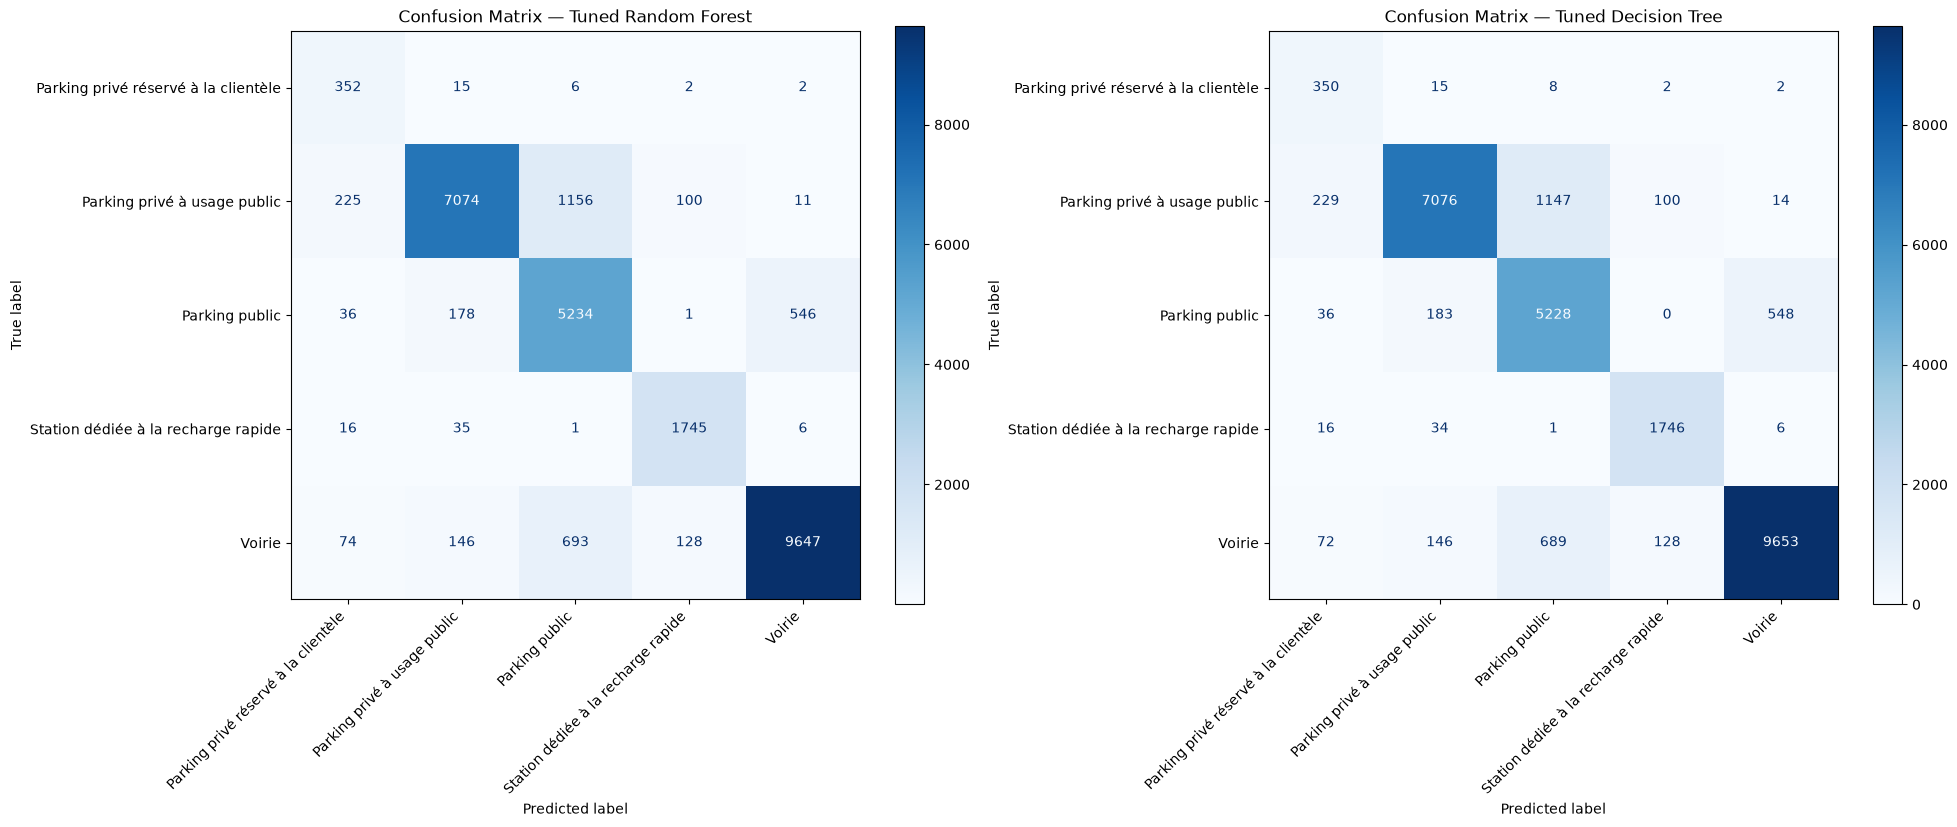

In [54]:
# Dernière comparaison visuelle : permet de mesurer l'apport du GridSearchCV
# par rapport aux matrices des blocs 12 et 15
# Crée une figure et un ensemble de sous-graphiques (axes) pour afficher les matrices.
# 1, 2: signifie 1 ligne et 2 colonnes de sous-graphiques.
# figsize=(20, 8): définit la taille de la figure en pouces.
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
for i, name in enumerate(tuned_models.keys()):
    model = tuned_models[name]
    # ConfusionMatrixDisplay.from_estimator: Crée et affiche une matrice de confusion.
    #   estimator (model): Le modèle entraîné à évaluer (ici, un modèle tuné).
    #   X (X_test_prep): Les données de test prétraitées (non rééchantillonnées).
    #   y (y_test): Les vraies étiquettes des données de test.
    #   display_labels=model.classes_: Les étiquettes à utiliser pour les classes (tirées du modèle).
    #   cmap=plt.cm.Blues: La carte de couleurs à utiliser pour la matrice.
    #   normalize=None: Ne normalise pas la matrice (affiche les comptes bruts).
    #   ax=axes[i]: Spécifie l'axe sur lequel dessiner la matrice de confusion.
    disp = ConfusionMatrixDisplay.from_estimator(
        model, X_test_prep, y_test,
        display_labels=model.classes_,
        cmap=plt.cm.Blues,
        normalize=None,
        ax=axes[i],
    )
    # Définit le titre de chaque sous-graphique.
    disp.ax_.set_title(f"Confusion Matrix — Tuned {name}")
    # Ajuste les propriétés des étiquettes de l'axe des x (rotation pour la lisibilité).
    plt.setp(disp.ax_.get_xticklabels(), rotation=45, ha="right")
    # Ajuste les propriétés des étiquettes de l'axe des y.
    plt.setp(disp.ax_.get_yticklabels(), rotation=0,  ha="right")

# Ajuste automatiquement les paramètres du subplot pour donner un ajustement serré.
plt.tight_layout()
# Affiche la figure avec toutes les matrices de confusion.
plt.show()

### Analyse des matrices de confusion (Après tuning)

Les matrices de confusion des modèles tunés (Random Forest et Decision Tree) sur le jeu de test, comparées à celles obtenues après SMOTE, révèlent une grande similarité dans la répartition des classifications:

- Stabilité de la détection des minoritaires: La classe 'Parking privé réservé à la clientèle' continue d'être très bien détectée, avec 350 instances correctement classées sur 377 réelles pour les deux modèles tunés. Le compromis observé après SMOTE (meilleur rappel au prix d'une légère baisse de précision) est maintenu. On observe des chiffres de faux positifs quasiment identiques pour les classes comme 'Parking privé à usage public' (115 pour RF et DT) et 'Parking public' (6 pour RF, 8 pour DT) qui sont prédites à tort comme 'Parking privé réservé à la clientèle'.

- Faible impact du tuning sur les confusions: Le tuning n'a pas fondamentalement modifié les schémas de confusion identifiés précédemment. Les erreurs persistent principalement entre les classes 'Parking privé à usage public', 'Parking public', et 'Voirie', qui sont les plus volumineuses et naturellement plus sujettes à des confusions. Cependant, ces confusions sont minimisées et les modèles continuent de montrer une forte performance globale sur ces classes.

GridSearchCV a permis de valider des hyperparamètres optimaux qui stabilisent les performances, notamment le F1-score pondéré en cross-validation, sans altérer significativement le comportement des modèles sur le test set en termes de matrices de confusion.

## 7. Sauvegarde du modèle final

Le Random Forest tuné est sélectionné comme modèle final en raison de sa performance légèrement supérieure en cross-validation et de sa robustesse généralement reconnue pour les problèmes de classification. Il est sauvegardé au format .pkl via joblib sur Google Drive, aux côtés du préprocesseur sauvegardé en section 3. Ces deux fichiers sont indissociables : pour faire une prédiction sur de nouvelles données, il faudra d'abord les transformer avec preprocessor .joblib, puis les passer au modèle.

In [56]:
# Sauvegarde du Random Forest tuné au format .pkl via joblib.
# Pour le recharger et l'utiliser :
#   model = joblib.load("tuned_random_forest_model.pkl")
#   y_pred = model.predict(X_new_prep)  # X_new_prep doit être préprocessé avec preprocessor.joblib
model_save_path = "tuned_random_forest_model.pkl"
#os.makedirs(os.path.dirname(model_save_path), exist_ok=True)
joblib.dump(tuned_models["Random Forest"], model_save_path)
print(f"Tuned Random Forest model saved to: {model_save_path}")

Tuned Random Forest model saved to: tuned_random_forest_model.pkl
